In [1]:
import copy
import math
import random

import matplotlib.pyplot as plt

from collections import defaultdict

from pathlib import Path

In [2]:
# Definição das distâncias entre cidades, onde os elementos de posição par são X e ímpar são Y

CSV = "0.77687122244663642,0.27943919986108079,0.5572653296455039,0.11661366329340583,0.65639441309858648,0.39053913424199571,0.60439895238077324,0.66616903964750607,0.10984792404443977,0.6985758378186272,0.30681838758814639,0.20730006383213373,0.036420458719028548,0.5024721283845478,0.50750194272285054,0.073938685056537334,0.79819787712259027,0.67991802460956252,0.79896874846157562,0.39749277989717913,0.14326939769923641,0.14151256215331487,0.071101926660729675,0.12773617026441342,0.72613149506352259,0.37197289724774407,0.22624105387667293,0.69033435138929333,0.6248041238023041,0.9189034809361033,0.5483227916626594,0.52333815217506263,0.39699387912590556,0.42525694545543524,0.075454958741316913,0.37166915101708831,0.67595096782693853,0.99033329254439939,0.074297051769727118,0.15694231625653665"

In [3]:
def get_duplicados(l: list) -> dict:
    d = defaultdict(list)

    for i, item in enumerate(l):
        d[item].append(i)

    return {item: locs for item, locs in d.items() if len(locs) > 1}


def get_distancias() -> tuple[list[float], list[float]]:
    distancias = CSV
    distancias = distancias.strip().split(",")
    distancias = [float(d) for d in distancias]

    x = [d for i, d in enumerate(distancias) if (i) % 2 == 0]
    y = [d for i, d in enumerate(distancias) if (i) % 2 != 0]

    return x, y


X, Y = get_distancias()

In [4]:
type Rota = list[int]

type Par = tuple[int, int]
type DistanciasCidades = dict[Par, float]


def get_rotas() -> list[Rota]:
    cidades = []  # [1,2,3,...,20]
    for i in range(20):
        cidades.append(i)

    r = []

    for i in range(20):
        rota = cidades.copy()
        random.shuffle(rota)  # embaralhar cidades de cada rota
        r.append(rota)

    return r


def get_rotas_ate_fim(rotas_originais: list[Rota]) -> list[Rota]:
    r = copy.deepcopy(rotas_originais)

    assert len(r) == 20, f"Esperado 20, obtive {len(r)}"

    for i in range(20):
        r[i].append(r[i][0])  # puxadinho

    return r


def get_distancia_entre_cidades(rotas: list[Rota]) -> DistanciasCidades:
    r = {}

    for i, _ in enumerate(rotas):
        for j, _ in enumerate(rotas[i]):
            custo_cidades = math.sqrt((X[i] - X[j]) ** 2 + (Y[i] - Y[j]) ** 2)

            r[(i, j)] = custo_cidades

    return r


def get_custos(
    distancias_cidades: DistanciasCidades, rotas_ate_fim: list[Rota], rotas: list[Rota]
) -> list[tuple[Rota, float]]:
    # cada rota tem 20 cidades, portanto 20 distancias
    # somar 20 distancias para cada rota_ate_fim (puxadinho)
    custos = []

    rotas = rotas.copy()
    rotas_ate_fim = rotas_ate_fim.copy()

    for i, rota in enumerate(rotas_ate_fim):  # rota = [2, 5, 1, ..., 20, 2]
        custos.append(0)

        for j in range(20):
            # 0,1
            # 1,2
            # 2,3
            # ...

            fst = j
            snd = j + 1

            custo_atual = distancias_cidades[(rota[fst], rota[snd])]

            custos[i] += custo_atual

    custos = list(zip(rotas, custos))
    custos = sorted(custos, key=lambda x: x[1])

    return custos


def rodar_roleta(idxs: list[int]) -> list[int]:
    roleta = []
    qtde_rotas = len(idxs)

    # distribui as rotas conforme
    # criterios da roleta - último tem 1 chance, penúltimo 2 chances, ...
    for i in range(qtde_rotas):
        # 0 = 10 vezes
        # 1 = 9 vezes
        # 2 = 8 vezes
        # ...

        to_add = 10 - i

        for i in range(to_add):
            roleta.append(idxs[i])

    return roleta


def coletar_pares_de_pais(roleta: list[int]) -> list[tuple[int, int]]:
    pares_de_pais = []

    # coleta pares de pais diferentes entre si
    # com base na roleta
    for _ in range(5):
        while True:
            p1_idx, p2_idx = random.sample(range(1, 55), 2)

            p1 = roleta[p1_idx]
            p2 = roleta[p2_idx]

            if p1 != p2:
                break

        pares_de_pais.append((p1, p2))

    return pares_de_pais


def cycling(pais: list[Par], custos: list[tuple[Rota, float]]) -> list[Rota]:
    filhos = []

    for i in range(len(pais)):
        p1, p2 = pais[i]
        p1 = custos[p1][0]
        p2 = custos[p2][0]

        p1 = p1.copy()
        p2 = p2.copy()

        swap = random.randint(0, 19)

        while True:
            pp1, pp2 = p2[swap], p1[swap]  # pp1 = p2[17] , pp2 = p1[17]
            p1[swap] = pp1  # trocar no p1
            p2[swap] = pp2  # trocar no p2

            # se uma não está repetida, a outra também não está,
            # então só precisa verificar uma rota
            repetido = get_duplicados(p1)

            if len(repetido) == 1:
                # trocar swap pelo repetido,
                # onde o repetido não é o swap atual

                r = list(repetido.values())[0]
                next_swap = [s for (s_i, s) in enumerate(r) if r[s_i] != swap]
                swap = next_swap[0]

                continue

            break

        f1 = p1.copy()
        f2 = p2.copy()

        filhos.append(f1)
        filhos.append(f2)

    return filhos


def crossover(filhos: list[Rota]) -> list[Rota]:
    filhos_mutados = []

    for i in range(len(filhos)):
        s_1, s_2 = random.sample(range(0, 19), 2)  # 18, 3

        f = filhos[i].copy()

        b_1 = f[s_1]  # 5 (i=18)
        b_2 = f[s_2]  # 2 (i=3)

        f[s_1] = b_2  # trocar os dois pontos
        f[s_2] = b_1  # trocar os dois pontos

        filhos_mutados.append(f)

    return filhos_mutados

In [5]:
def rodar_algoritmo(rotas_iniciais: list[Rota] = None, I: int = 10_000) -> list[tuple[Rota, float]]:
    def custos_iniciais() -> list[tuple[Rota, float]]:
        _distancias_cidades = get_distancia_entre_cidades(rotas_iniciais)
        _rotas_ate_fim = get_rotas_ate_fim(rotas_iniciais)
        _custos = get_custos(_distancias_cidades, _rotas_ate_fim, rotas_iniciais)

        return _custos

    _custos = custos_iniciais()
    _resultados: list[list[tuple[Rota, float]]] = []

    for _ in range(I):
        _dez_melhores_custos = _custos[:10]
        _dez_melhores_rotas = [r for r, _ in _dez_melhores_custos]
        _dez_melhores_custos_idxs = [i for i, _ in enumerate(_dez_melhores_custos)]

        _roleta = rodar_roleta(_dez_melhores_custos_idxs)

        _pares_de_pais = coletar_pares_de_pais(_roleta)

        _filhos = crossover(cycling(_pares_de_pais, _custos))

        _novas_rotas = _dez_melhores_rotas + _filhos
        _novas_distancias = get_distancia_entre_cidades(_novas_rotas)
        _novas_rotas_ate_fim = get_rotas_ate_fim(_novas_rotas)

        _custos = get_custos(_novas_distancias, _novas_rotas_ate_fim, _novas_rotas)

        _resultados.append(_custos)

    return _resultados

--- Resumo do Algoritmo Genético ---
População Inicial: 20 rotas
População Final (total de rotas avaliadas): 200000 rotas
Quantidade de Cidades: 20
Melhor Custo Encontrado: 4.0814
Melhor Solução (rota): [2, 12, 0, 9, 8, 18, 14, 3, 1, 7, 16, 13, 4, 6, 17, 19, 11, 10, 5, 15]


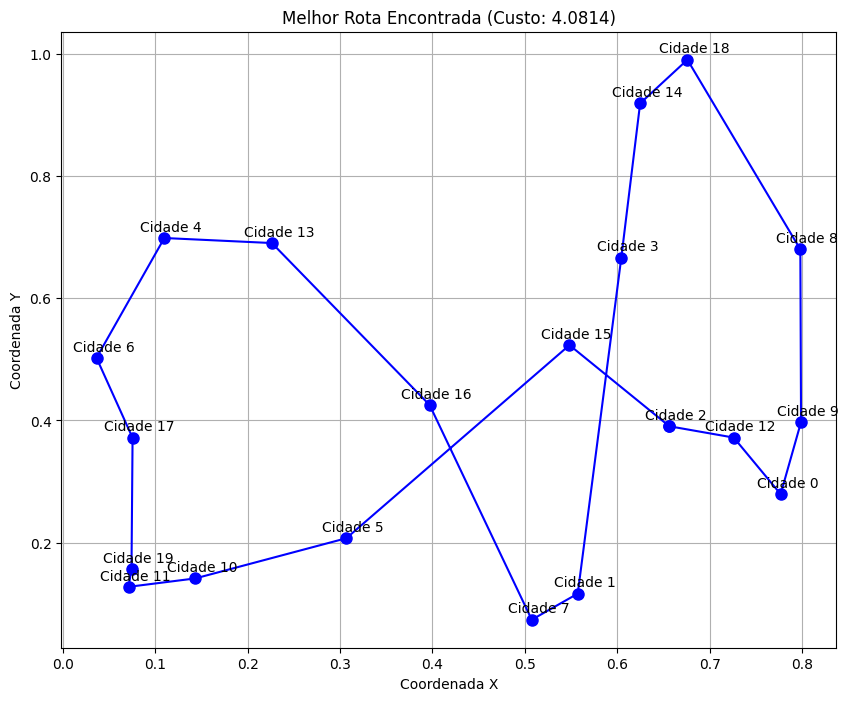

In [6]:
print(f"--- Resumo do Algoritmo Genético ---")

rotas_iniciais = get_rotas()

rotas_finais = rodar_algoritmo(rotas_iniciais)
rotas_finais_flat = sorted([resultado for sublist in rotas_finais for resultado in sublist], key=lambda x: x[1])

print(f"População Inicial: {len(rotas_iniciais)} rotas")
print(f"População Final (total de rotas avaliadas): {len(rotas_finais_flat)} rotas")

melhor_rota_caminho, melhor_rota_custo = rotas_finais_flat[0]
print(f"Quantidade de Cidades: {len(melhor_rota_caminho)}")
print(f"Melhor Custo Encontrado: {melhor_rota_custo:.4f}")
print(f"Melhor Solução (rota): {melhor_rota_caminho}")

x = [X[i] for i in melhor_rota_caminho]
y = [Y[i] for i in melhor_rota_caminho]

x.append(X[melhor_rota_caminho[0]])
y.append(Y[melhor_rota_caminho[0]])

plt.figure(figsize=(10, 8))
plt.plot(x, y, marker='o', linestyle='-', color='blue', markersize=8)

# Label de cidades
for i, city_idx in enumerate(melhor_rota_caminho):
    plt.annotate(f'Cidade {city_idx}', (X[city_idx], Y[city_idx]), textcoords="offset points", xytext=(5,5), ha='center')

plt.title(f'Melhor Rota Encontrada (Custo: {melhor_rota_custo:.4f})')
plt.xlabel('Coordenada X')
plt.ylabel('Coordenada Y')
plt.grid(True)
plt.show()